In [30]:
import os, json, time, gc, warnings, random
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import joblib
import matplotlib.pyplot as plt 
import seaborn as sns 

import tensorflow as tf 
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, BatchNormalization,
                                     SpatialDropout1D, Dropout, Dense, LSTM,
                                     Bidirectional, GlobalAveragePooling1D,
                                     LayerNormalization)
from tensorflow.keras.layers import MultiHeadAttention, Add
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# reproducibility
SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

In [31]:
df1 = pd.read_csv('mydata.csv')
df1.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [32]:
df1.columns = df1.columns.str.strip()

In [33]:
df1['Label'].value_counts()

Label
BENIGN                        1984531
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [34]:
df1.shape

(2542141, 79)

In [35]:
df1.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64

In [36]:
df1.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,...,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06,2.542141e+06
mean,8.057795e+03,1.544539e+07,9.716660e+00,1.086743e+01,5.473822e+02,1.729797e+04,2.151780e+02,1.888957e+01,6.007840e+01,7.210913e+01,...,5.643280e+00,-3.055860e+03,8.384228e+04,4.108791e+04,1.555291e+05,6.058808e+04,8.963907e+06,5.473023e+05,9.376316e+06,8.537139e+06
std,1.836861e+04,3.421694e+07,7.906831e+02,1.051811e+03,5.843776e+03,2.387238e+06,7.420455e+02,6.275191e+01,1.921477e+02,2.928974e+02,...,6.713710e+02,1.144922e+06,6.616263e+05,3.951051e+05,1.036473e+06,5.905368e+05,2.459048e+07,4.823905e+06,2.535527e+07,2.432128e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.660000e+02,1.000000e+00,1.000000e+00,1.200000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.423400e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.300000e+02,3.800000e+01,2.000000e+00,3.500000e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,4.291053e+06,5.000000e+00,5.000000e+00,2.800000e+02,6.030000e+02,1.800000e+02,3.600000e+01,5.085714e+01,3.111270e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,2.428415e+06,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [37]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2542141 entries, 0 to 2542140
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow IAT Mi

In [38]:
def clean_cic2017(df: pd.DataFrame) -> pd.DataFrame:
    dfc = df.copy()
    
    # Normalize column name 
    dfc.columns = [c.strip().replace(" ","_") for c in dfc.columns]
    
    drop_cols = [c for c in [
        "Timestamp","Flow_ID",
        "Source_IP","Destination_IP","Source_Port","Destination_Port",
        "Src_IP","Dst_IP","Src_Port","Dst_Port"
    ] if c in dfc.columns]
    
    if drop_cols:
        dfc.drop(columns=drop_cols, inplace=True, errors="ignore")
        
    assert "Label" in dfc.columns, "Missing Label column"
    dfc["Label"] = (
        dfc["Label"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"normal":"benign"})
    )
    
    feats = [c for c in dfc.columns if c != "Label"]
    for c in feats:
        dfc[c] = pd.to_numeric(dfc[c],errors="coerce")
        
    dfc.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfc[feats] = dfc[feats].fillna(0)
    
    return dfc 

In [39]:
def normalize_label_2017(s: str) -> str:
    s = s.lower().strip()
    s = s.replace('web attack –', 'web attack -').replace('web attack —','web attack -').replace('web attack �','web attack -')
    if any(k in s for k in ['hulk','goldeneye','slowloris','slowhttptest']): return 'dos'
    if 'ddos' in s: return 'ddos'
    if any(k in s for k in ['ftp-patator','ssh-patator','brute force']): return 'bruteforce'
    if 'portscan' in s or 'port scan' in s: return 'portscan'
    if 'web attack' in s or 'xss' in s or 'sql injection' in s: return 'webattack'
    if 'bot' in s: return 'bot'
    if 'infiltration' in s: return 'infiltration'
    if 'benign' in s: return 'benign'
    return s

In [40]:
df = clean_cic2017(df1)
df["Label"] = df["Label"].astype(str).map(normalize_label_2017)
print("After clean :", df.shape)
print(df["Label"].value_counts())

After clean : (2542141, 78)
Label
benign        1984531
dos            252661
portscan       158930
ddos           128027
bruteforce      15342
bot              1966
webattack         673
heartbleed         11
Name: count, dtype: int64


In [41]:
MAX_PER_CLASS = 30000

parts = []
for label, group in df.groupby("Label"):
    parts.append(group.sample(n=min(len(group), MAX_PER_CLASS), random_state=SEED))

df_bal = pd.concat(parts).reset_index(drop=True)

print("Balanced shape:", df_bal.shape)
print(df_bal["Label"].value_counts())

le = LabelEncoder()
df_bal["Label"] = le.fit_transform(df_bal["Label"])

classes = list(le.classes_)
print("\nClasses:", classes)

ART_DIR = "artifacts"
os.makedirs(ART_DIR, exist_ok=True)
joblib.dump(le, os.path.join(ART_DIR, "label_encoder.pkl"))

Balanced shape: (137992, 78)
Label
benign        30000
ddos          30000
dos           30000
portscan      30000
bruteforce    15342
bot            1966
webattack       673
heartbleed       11
Name: count, dtype: int64

Classes: ['benign', 'bot', 'bruteforce', 'ddos', 'dos', 'heartbleed', 'portscan', 'webattack']


['artifacts\\label_encoder.pkl']

In [42]:
from sklearn.utils import resample

parts = []
for label, group in df.groupby("Label"):
    n = len(group)
    
    if n < 1000:
        
        group_resampled = resample(
            group,
            replace=True,        
            n_samples=5000,      
            random_state=SEED
        )
        parts.append(group_resampled)
    else:
        parts.append(group.sample(
            n=min(len(group), 30000),
            random_state=SEED
        ))

In [43]:
df_bal = pd.concat(parts).reset_index(drop=True)
print("New distribution:")
print(df_bal["Label"].value_counts())

New distribution:
Label
benign        30000
ddos          30000
dos           30000
portscan      30000
bruteforce    15342
heartbleed     5000
webattack      5000
bot            1966
Name: count, dtype: int64


In [44]:
le = LabelEncoder()
df_bal["Label"] = le.fit_transform(df_bal["Label"])  # text → numbers
classes = list(le.classes_)
print("Classes:", classes)

joblib.dump(le, os.path.join(ART_DIR, "label_encoder.pkl"))

Classes: ['benign', 'bot', 'bruteforce', 'ddos', 'dos', 'heartbleed', 'portscan', 'webattack']


['artifacts\\label_encoder.pkl']

In [45]:
X = df_bal.drop(columns=["Label"])
y = df_bal["Label"].astype(int)

X_train, X_test, y_train_idx, y_test_idx = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print("Split:",
      "\n  X_train:", X_train.shape,
      "\n  X_test :", X_test.shape)

Split: 
  X_train: (117846, 77) 
  X_test : (29462, 77)


In [46]:
selector = VarianceThreshold(0.01)
X_train_sel = selector.fit_transform(X_train)
X_test_sel  = selector.transform(X_test)

scaler = RobustScaler(quantile_range=(5,95))
X_train_ml = scaler.fit_transform(X_train_sel)
X_test_ml  = scaler.transform(X_test_sel)

# one-hot
num_classes = len(classes)
y_train_cnn = to_categorical(y_train_idx, num_classes)
y_test_cnn  = to_categorical(y_test_idx,  num_classes)

In [47]:
def pp(d): print(json.dumps(d, indent=2, ensure_ascii=False))

X_train_cnn = X_train_ml[..., np.newaxis]
X_test_cnn  = X_test_ml[...,  np.newaxis]

cls = np.unique(y_train_idx)
cw_values = compute_class_weight(class_weight="balanced", classes=cls, y=y_train_idx)
class_weight = {int(c): float(w) for c, w in zip(cls, cw_values)}
pp({"class_weight": class_weight})

joblib.dump(selector, os.path.join(ART_DIR, "selector.pkl"))
joblib.dump(scaler,   os.path.join(ART_DIR, "scaler.pkl"))

print("\n=== PREP SUMMARY ===")
print(f"ML 2D  -> X_train: {X_train_ml.shape}, X_test: {X_test_ml.shape}")
print(f"CNN 3D -> X_train: {X_train_cnn.shape}, X_test: {X_test_cnn.shape}")
print(f"y_train (idx/oh): {y_train_idx.shape} / {y_train_cnn.shape}")

np.savez_compressed(
    os.path.join(ART_DIR, "prepared_train_test.npz"),
    X_train_ml=X_train_ml, X_test_ml=X_test_ml,
    y_train_idx=y_train_idx, y_test_idx=y_test_idx,
    X_train_cnn=X_train_cnn, X_test_cnn=X_test_cnn,
    y_train_cnn=y_train_cnn, y_test_cnn=y_test_cnn,
)

{
  "class_weight": {
    "0": 0.61378125,
    "1": 9.36474888747616,
    "2": 1.2002566609630898,
    "3": 0.61378125,
    "4": 0.61378125,
    "5": 3.6826875,
    "6": 0.61378125,
    "7": 3.6826875
  }
}

=== PREP SUMMARY ===
ML 2D  -> X_train: (117846, 65), X_test: (29462, 65)
CNN 3D -> X_train: (117846, 65, 1), X_test: (29462, 65, 1)
y_train (idx/oh): (117846,) / (117846, 8)


In [48]:
timesteps = X_train_cnn.shape[1]
channels  = X_train_cnn.shape[2]

inputs = Input(shape=(timesteps, channels), name="inputs")

# CNN feature extractor + regularization
x = Conv1D(128, 3, padding='same', activation='relu', kernel_regularizer=l2(1e-4))(inputs)
x = BatchNormalization()(x)
x = SpatialDropout1D(0.2)(x)
x = MaxPooling1D(2, padding='same')(x)

x = Conv1D(256, 3, padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = SpatialDropout1D(0.2)(x)
x = MaxPooling1D(2, padding='same')(x)

x = Bidirectional(LSTM(128, return_sequences=True), name="bilstm")(x)

# Multi-Head Self-Attention + LayerNorm
attn_out = MultiHeadAttention(num_heads=4, key_dim=64, name="mha")(x, x)
x = Add()([x, attn_out])                # residual
x = LayerNormalization()(x)

x = GlobalAveragePooling1D(name="gap")(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation='softmax', name="softmax")(x)

attn_model = Model(inputs, outputs, name="CNN_BiLSTM_Attn_CIC2017")

attn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="Precision"),
             tf.keras.metrics.Recall(name="Recall")]
)

attn_model.summary()

Model: "CNN_BiLSTM_Attn_CIC2017"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 65, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 65, 128)   │        512 │ inputs[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 65, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 65, 128)   │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 33, 128)   │          0 │ spatial_dropout1… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 33, 256)   │     98,560 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 256)   │      1,024 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 33, 256)   │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 17, 256)   │          0 │ spatial_dropout1… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 17, 256)   │    394,240 │ max_pooling1d_3[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 17, 256)   │    263,168 │ bilstm[0][0],     │
│ (MultiHeadAttentio… │                   │            │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 17, 256)   │          0 │ bilstm[0][0],     │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 17, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 8)         │      1,032 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 792,456 (3.02 MB)

 Trainable params: 791,688 (3.02 MB)

 Non-trainable params: 768 (3.00 KB)

In [49]:
batch_size = 256

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_cnn, y_train_cnn))
train_dataset = train_dataset.shuffle(len(X_train_cnn), seed=SEED)
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_test_cnn, y_test_cnn))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# sanity
xb, yb = next(iter(train_dataset))
print("Sanity shapes:", xb.shape, yb.shape)
print("One forward:", attn_model(xb, training=False).shape)

Sanity shapes: (256, 65, 1) (256, 8)
One forward: (256, 8)


In [50]:
LOG_JSON = os.path.join(ART_DIR, "train_test_logs.json")
LOG_CSV  = os.path.join(ART_DIR, "train_epoch_logs.csv")

class CSVLoggerLite(tf.keras.callbacks.Callback):
    def __init__(self, path):
        super().__init__()
        self.path = path
        self.cols = None
        with open(self.path, "w") as f:
            f.write("epoch,loss,accuracy,Precision,Recall,val_loss,val_accuracy,val_Precision,val_Recall\n")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        if self.cols is None:
            self.cols = list(logs.keys())
        row = [epoch] + [logs.get(k, np.nan) for k in ["loss","accuracy","Precision","Recall",
                                                       "val_loss","val_accuracy","val_Precision","val_Recall"]]
        with open(self.path, "a") as f:
            f.write(",".join(str(x) for x in row) + "\n")

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
    tf.keras.callbacks.TerminateOnNaN(),
    CSVLoggerLite(LOG_CSV),
]

start = time.time()
history = attn_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - start
print(f"Training done in {train_time:.1f}s")

Epoch 1/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 272s 543ms/step - Precision: 0.7334 - Recall: 0.4403 - accuracy: 0.5922 - loss: 1.0404 - val_Precision: 0.3793 - val_Recall: 0.2060 - val_accuracy: 0.4342 - val_loss: 1.9468 - learning_rate: 1.0000e-04
Epoch 2/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 233s 505ms/step - Precision: 0.8575 - Recall: 0.7804 - accuracy: 0.8224 - loss: 0.5003 - val_Precision: 0.8983 - val_Recall: 0.8660 - val_accuracy: 0.8806 - val_loss: 0.3790 - learning_rate: 1.0000e-04
Epoch 3/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 307s 665ms/step - Precision: 0.9041 - Recall: 0.8630 - accuracy: 0.8843 - loss: 0.3458 - val_Precision: 0.9281 - val_Recall: 0.9181 - val_accuracy: 0.9240 - val_loss: 0.2710 - learning_rate: 1.0000e-04
Epoch 4/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 319s 675ms/step - Precision: 0.9283 - Recall: 0.9009 - accuracy: 0.9154 - loss: 0.2717 - val_Precision: 0.9382 - val_Recall: 0.9304 - val_accuracy: 0.9332 - val_loss: 0.2244 - learning_rate: 1.0000e-04
Epoch 5/20
461/461 ━━━━━━━━━━━━━


Evaluating model...

=== 📊 Evaluation Metrics (Overall) ===
Accuracy  : 0.9705 (97.05%)
Precision : 0.9749 (97.49%)
Recall    : 0.9705 (97.05%)
F1-Score  : 0.9714 (97.14%)

=== Classification report ===
              precision    recall  f1-score   support

      benign     0.9947    0.9115    0.9513      6000
         bot     0.6883    1.0000    0.8154       393
  bruteforce     0.9418    0.9114    0.9263      3069
        ddos     0.9988    0.9983    0.9986      6000
         dos     0.9769    0.9958    0.9863      6000
  heartbleed     1.0000    1.0000    1.0000      1000
    portscan     0.9990    0.9985    0.9987      6000
   webattack     0.7449    0.9780    0.8457      1000

    accuracy                         0.9705     29462
   macro avg     0.9180    0.9742    0.9403     29462
weighted avg     0.9749    0.9705    0.9714     29462



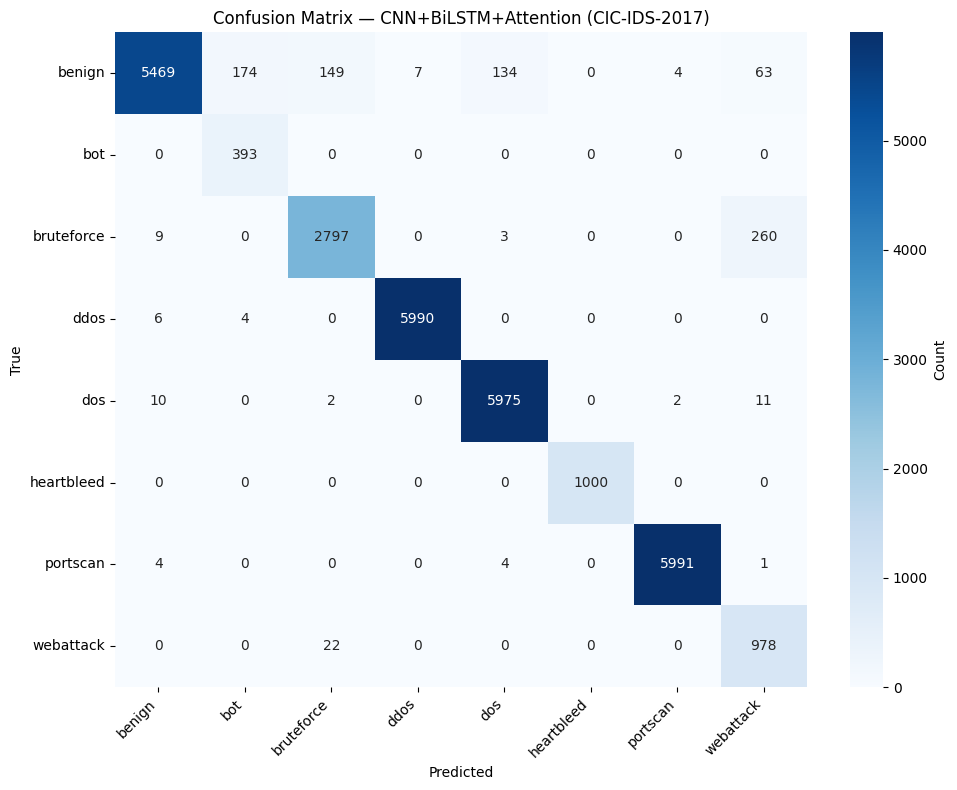


Saved logs to:
 - artifacts\train_epoch_logs.csv
 - artifacts\train_test_logs.json




✅ Model saved at: cnn_bilstm_attention_model.h5


In [51]:
print("\nEvaluating model...")
y_pred_probs = attn_model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_idx

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\n=== 📊 Evaluation Metrics (Overall) ===")
print(f"Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall    : {rec:.4f} ({rec*100:.2f}%)")
print(f"F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

# per-class report
print("\n=== Classification report ===")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label':'Count'})
plt.title("Confusion Matrix — CNN+BiLSTM+Attention (CIC-IDS-2017)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# save logs (train summary + test metrics)
logs = {
  "dataset": "CIC-IDS-2017",
  "classes": classes,
  "train_time_sec": train_time,
  "best_val": {
      "loss": float(np.min(history.history["val_loss"])),
      "accuracy": float(np.max(history.history["val_accuracy"])),
      "precision": float(np.max(history.history["val_Precision"])),
      "recall": float(np.max(history.history["val_Recall"]))
  },
  "test_metrics": {
      "accuracy": float(acc), "precision": float(prec),
      "recall": float(rec), "f1": float(f1)
  }
}
with open(LOG_JSON, "w") as f:
    json.dump(logs, f, indent=2)

print("\nSaved logs to:")
print(" -", LOG_CSV)
print(" -", LOG_JSON)

# clear session to free VRAM
tf.keras.backend.clear_session()
gc.collect();

#  Save Model
model_path = "cnn_bilstm_attention_model.h5"
attn_model.save("cnn_bilstm_attention_model1.keras")
attn_model.save(model_path)

print(f"\n✅ Model saved at: {model_path}")

attn_scores shape: (8, 4, 17, 17)


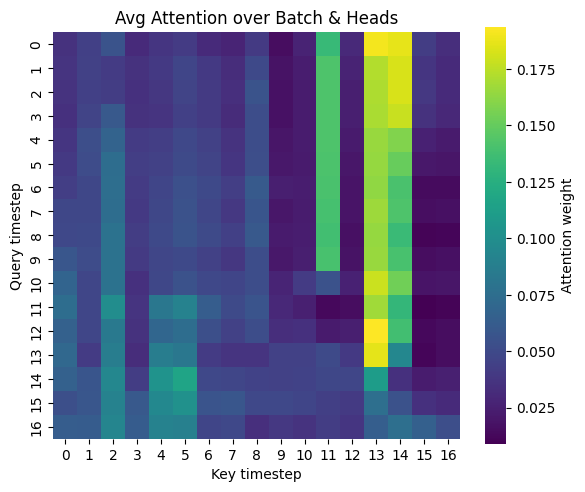

In [52]:
bilstm_model = Model(
    inputs  = attn_model.input,
    outputs = attn_model.get_layer('bilstm').output
)

# Step 2: MHA manually call karo
mha_layer  = attn_model.get_layer('mha')
n_samples  = 8

bilstm_out = bilstm_model.predict(X_test_cnn[:n_samples], verbose=0)
bilstm_tf  = tf.constant(bilstm_out, dtype=tf.float32)

_, attn_scores = mha_layer(
    bilstm_tf, bilstm_tf,
    return_attention_scores=True,
    training=False
)
attn_scores = attn_scores.numpy()
print("attn_scores shape:", attn_scores.shape)

if attn_scores.ndim == 4:
    attn_mean = attn_scores.mean(axis=1)   # heads average
else:
    attn_mean = attn_scores

avg_map = attn_mean.mean(axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(avg_map, cmap='viridis', square=True,
            cbar_kws={'label': 'Attention weight'})
plt.title("Avg Attention over Batch & Heads")
plt.xlabel("Key timestep")
plt.ylabel("Query timestep")
plt.tight_layout()
plt.show()


Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1,Training Time (s)
0,RandomForest,0.983674,0.984532,0.983674,0.983867,7.806525
1,CNN+BiLSTM+Attention,0.970504,0.974903,0.970504,0.971370,5020.973687
2,DecisionTree,0.927364,0.920161,0.927364,0.922829,2.376206
3,SGD,0.860634,0.855862,0.860634,0.848162,11.711461
4,NaiveBayes,0.648768,0.853967,0.648768,0.678542,0.487746
5,LogReg,0.497794,0.383590,0.497794,0.402907,189.669244


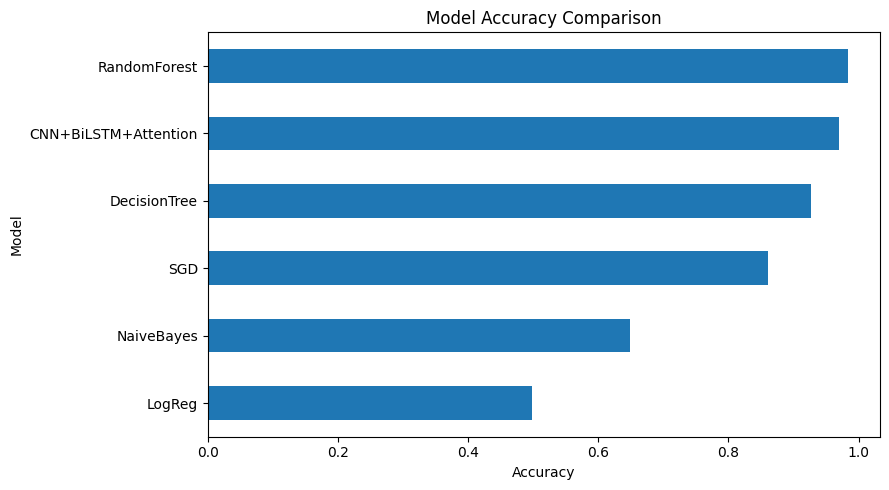

In [53]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

ml_models = {
    "SGD": make_pipeline(SelectKBest(f_classif, k=30),
                         SGDClassifier(loss="modified_huber", max_iter=1000, tol=1e-3, random_state=SEED)),
    "LogReg": make_pipeline(SelectKBest(f_classif, k=30),
                            LogisticRegression(solver="saga", max_iter=500, n_jobs=-1, random_state=SEED)),  # ← multi_class hata diya
    "NaiveBayes": make_pipeline(SelectKBest(f_classif, k=30), GaussianNB()),
    "DecisionTree": make_pipeline(SelectKBest(f_classif, k=30),
                                 DecisionTreeClassifier(max_depth=10, min_samples_split=50, ccp_alpha=0.01, random_state=SEED)),
    "RandomForest": make_pipeline(SelectKBest(f_classif, k=30),
                                  RandomForestClassifier(n_estimators=80, max_depth=14, n_jobs=-1, random_state=SEED))
}

results = []
for name, mdl in ml_models.items():
    t0 = time.time()
    mdl.fit(X_train_ml, y_train_idx)
    tr_time = time.time() - t0
    yp = mdl.predict(X_test_ml)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_idx, yp),
        "Precision": precision_score(y_test_idx, yp, average="weighted", zero_division=0),
        "Recall": recall_score(y_test_idx, yp, average="weighted", zero_division=0),
        "F1": f1_score(y_test_idx, yp, average="weighted", zero_division=0),
        "Training Time (s)": tr_time
    })

# thêm DL model vào bảng so sánh
results.append({
    "Model": "CNN+BiLSTM+Attention",
    "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "Training Time (s)": train_time
})

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
print("\nFinal Model Comparison:")
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["Accuracy","F1"]))

plt.figure(figsize=(9,5))
(results_df.set_index('Model')['Accuracy']
 .sort_values()
 .plot(kind='barh', title='Model Accuracy Comparison'))
plt.xlabel("Accuracy"); plt.tight_layout(); plt.show()
